# 🚢 Titanic EDA - Análisis Exploratorio de Datos

**Objetivo:** ¿Qué factores determinaron quién sobrevivió al hundimiento del Titanic?

En este notebook se va a:

* Explorar y entender los datos del Titanic
* Limpiar y preparar los datos
* Crear visualizaciones para encontrar patrones
* Responder preguntas sobre la supervivencia

## 🛠️ Paso 0: Configuración Inicial

Importar todas las librerías necesarias para el análisis.

**Librerías a importar:**

* pandas (como pd)
* numpy (como np)
* matplotlib.pyplot (como plt)
* seaborn (como sns)
* kagglehub
* os

**Configuración de gráficos:**

* Se establece el estilo de seaborn como "whitegrid"
* Se configura el tamaño de figura por defecto: (10, 6)

In [14]:
!pip install kagglehub

import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
import kagglehub
import os

# Configuración para que los gráficos se vean mejor
sns.set_style("whitegrid")
plt.rcParams['figure.figsize'] = (10, 6)

## 📥 Paso 1: Cargar los Datos

Descargar el dataset del Titanic usando kagglehub y cárgalo en un DataFrame.

**Tareas:**

1. Usar kagglehub.dataset_download("yasserh/titanic-dataset") para descargar
2. Guardar la ruta en una variable path
3. Cargar el archivo 'Titanic-Dataset.csv' usando pd.read_csv()
4. Guardar el DataFrame en la variable df

In [26]:
# Descargar el dataset del Titanic desde Kaggle
path = kagglehub.dataset_download("yasserh/titanic-dataset")
print("Path to dataset files:", path)

# Cargar el archivo Titanic-Dataset.csv
df = pd.read_csv(os.path.join(path, 'Titanic-Dataset.csv'))

Path to dataset files: C:\Users\usuario\.cache\kagglehub\datasets\yasserh\titanic-dataset\versions\1


## 👀 Paso 2: Primera Exploración

Examinar las primeras filas del dataset para familiarizarte con los datos.

### 2.1 Ver las primeras filas

Usar df.head() para ver las primeras 5 filas del dataset.

In [18]:
df.head()

,PassengerId,Survived,Pclass,Name,Sex,Age,SibSp,Parch,Ticket,Fare,Cabin,Embarked
0,1,0,3,"Braund, Mr. Owen Harris",male,22.0,1,0,A/5 21171,7.2500,NaN,S
1,2,1,1,"Cumings, Mrs. John Bradley (Florence Briggs Th...",female,38.0,1,0,PC 17599,71.2833,C85,C
2,3,1,3,"Heikkinen, Miss. Laina",female,26.0,0,0,STON/O2. 3101282,7.9250,NaN,S
3,4,1,1,"Futrelle, Mrs. Jacques Heath (Lily May Peel)",female,35.0,1,0,113803,53.1000,C123,S
4,5,0,3,"Allen, Mr. William Henry",male,35.0,0,0,373450,8.0500,NaN,S


### 2.2 Dimensiones del dataset

Imprimir cuántas filas (pasajeros) y columnas (características) tiene el dataset

**Pista:** Usar df.shape

In [27]:
df.shape
print(f"Filas: {df.shape[0]}, Columnas: {df.shape[1]}")

Filas: 891, Columnas: 12


### 2.3 Información general

Usar df.info() para ver:

* Tipos de datos de cada columna
* Cantidad de valores no nulos
* Memoria que ocupa

In [20]:
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 891 entries, 0 to 890
Data columns (total 12 columns):
 #   Column       Non-Null Count  Dtype  
---  ------       --------------  -----  
 0   PassengerId  891 non-null    int64  
 1   Survived     891 non-null    int64  
 2   Pclass       891 non-null    int64  
 3   Name         891 non-null    object 
 4   Sex          891 non-null    object 
 5   Age          714 non-null    float64
 6   SibSp        891 non-null    int64  
 7   Parch        891 non-null    int64  
 8   Ticket       891 non-null    object 
 9   Fare         891 non-null    float64
 10  Cabin        204 non-null    object 
 11  Embarked     889 non-null    object 
dtypes: float64(2), int64(5), object(5)
memory usage: 83.7+ KB


### 2.4 Columnas disponibles

Muestra la lista de todas las columnas del dataset.

**Pista:** Usar df.columns.tolist()

In [28]:
print(df.columns.tolist())

['PassengerId', 'Survived', 'Pclass', 'Name', 'Sex', 'Age', 'SibSp', 'Parch', 'Ticket', 'Fare', 'Cabin', 'Embarked']


## 📊 Paso 3: Estadística Descriptiva

Obtener un resumen estadístico de las variables numéricas.

### 3.1 Estadísticas de variables numéricas

Usar df.describe() para ver:

* Promedio (mean)
* Desviación estándar (std)
* Valores mínimo y máximo
* Percentiles (25%, 50%, 75%)

In [22]:
df.describe()

,PassengerId,Survived,Pclass,Age,SibSp,Parch,Fare
count,891.000000,891.000000,891.000000,714.000000,891.000000,891.000000,891.000000
mean,446.000000,0.383838,2.308642,29.699118,0.523008,0.381594,32.204208
std,257.353842,0.486592,0.836071,14.526497,1.102743,0.806057,49.693429
min,1.000000,0.000000,1.000000,0.420000,0.000000,0.000000,0.000000
25%,223.500000,0.000000,2.000000,20.125000,0.000000,0.000000,7.910400
50%,446.000000,0.000000,3.000000,28.000000,0.000000,0.000000,14.454200
75%,668.500000,1.000000,3.000000,38.000000,1.000000,0.000000,31.000000
max,891.000000,1.000000,3.000000,80.000000,8.000000,6.000000,512.329200


### 3.2 Estadísticas de variables categóricas

Usar df.describe(include='object') para analizar las columnas de texto.

In [23]:
df.describe(include='object')

,Name,Sex,Ticket,Cabin,Embarked
count,891,891,891,204,889
unique,891,2,681,147,3
top,"Braund, Mr. Owen Harris",male,347082,B96 B98,S
freq,1,577,7,4,644


## 🧹 Paso 4: Limpieza de Datos

### 4.1 Identificar valores faltantes

Encontrar cuántos valores faltantes (NaN) hay en cada columna.

**Pista:** Usar df.isnull().sum()

In [24]:
print(df.isnull().sum())

PassengerId      0
Survived         0
Pclass           0
Name             0
Sex              0
Age            177
SibSp            0
Parch            0
Ticket           0
Fare             0
Cabin          687
Embarked         2
dtype: int64


### 4.2 Visualizar valores faltantes (porcentaje)

Usando el paquete missigno para visualizar los datos faltante

Calcula el porcentaje de datos faltantes por columna.

**Formula:** (valores faltantes / total de filas) * 100

Muestra solo las columnas que tienen valores faltantes (porcentaje > 0).

In [32]:
# Porcentaje de datos faltantes por columna
missing_percent = (df.isnull().sum() / len(df)) * 100
print(missing_percent[missing_percent > 0])

Age         19.865320
Cabin       77.104377
Embarked     0.224467
dtype: float64


### 4.3 Eliminar columnas irrelevantes

Eliminar las siguientes columnas que no aportan al análisis:

* PassengerId
* Name
* Ticket
* Cabin

**Pista:** Usar df.drop([columnas], axis=1)

Después, mostrar las primeras filas con df.head() para verificar.

In [33]:
# Eliminar columnas que no aportan al análisis
df = df.drop(['PassengerId', 'Name', 'Ticket', 'Cabin'], axis=1)

# Ver cómo quedó el dataset después de eliminar columnas
print("Dataset después de eliminar columnas:")
df.head()

Dataset después de eliminar columnas:


,Survived,Pclass,Sex,Age,SibSp,Parch,Fare,Embarked
0,0,3,male,22.0,1,0,7.2500,S
1,1,1,female,38.0,1,0,71.2833,C
2,1,3,female,26.0,0,0,7.9250,S
3,1,1,female,35.0,1,0,53.1000,S
4,0,3,male,35.0,0,0,8.0500,S


### 4.4 Imputar valores faltantes en Age

Rellenar los valores faltantes de la columna 'Age' con la **mediana**.

**Pasos:**

1. Calcular la mediana de Age: df['Age'].median()
2. Rellenar los valores faltantes: df['Age'].fillna(mediana, inplace=True)
3. Mostrar las primeras 10 filas para verificar

In [34]:
# La mediana es más robusta que el promedio ante valores extremos
median_age = df['Age'].median()
df['Age'].fillna(median_age, inplace=True)

# Ver las primeras filas para confirmar que se llenaron los valores faltantes
print(f"Valores de Age imputados con la mediana: {median_age}")
df.head(10)

Valores de Age imputados con la mediana: 28.0


C:\Users\usuario\AppData\Local\Temp\ipykernel_6252\4077525032.py:3: FutureWarning: A value is trying to be set on a copy of a DataFrame or Series through chained assignment using an inplace method.
The behavior will change in pandas 3.0. This inplace method will never work because the intermediate object on which we are setting values always behaves as a copy.

For example, when doing 'df[col].method(value, inplace=True)', try using 'df.method({col: value}, inplace=True)' or df[col] = df[col].method(value) instead, to perform the operation inplace on the original object.


  df['Age'].fillna(median_age, inplace=True)


,Survived,Pclass,Sex,Age,SibSp,Parch,Fare,Embarked
0,0,3,male,22.0,1,0,7.2500,S
1,1,1,female,38.0,1,0,71.2833,C
2,1,3,female,26.0,0,0,7.9250,S
3,1,1,female,35.0,1,0,53.1000,S
4,0,3,male,35.0,0,0,8.0500,S
5,0,3,male,28.0,0,0,8.4583,Q
6,0,1,male,54.0,0,0,51.8625,S
7,0,3,male,2.0,3,1,21.0750,S
8,1,3,female,27.0,0,2,11.1333,S
9,1,2,female,14.0,1,0,30.0708,C


### 4.5 Imputar valores faltantes en Embarked

Rellenar los valores faltantes de 'Embarked' con la **moda** (valor más frecuente).

**Pasos:**

1. Calcular la moda: df['Embarked'].mode()[0]
2. Rellenar los valores faltantes
3. Mostrar las primeras 10 filas

In [35]:
# La moda es el valor más frecuente
mode_embarked = df['Embarked'].mode()[0]
df['Embarked'].fillna(mode_embarked, inplace=True)

# Verificar que se imputaron los valores
print(f"Valores de Embarked imputados con la moda: {mode_embarked}")
df.head(10)

Valores de Embarked imputados con la moda: S


C:\Users\usuario\AppData\Local\Temp\ipykernel_6252\2896098006.py:3: FutureWarning: A value is trying to be set on a copy of a DataFrame or Series through chained assignment using an inplace method.
The behavior will change in pandas 3.0. This inplace method will never work because the intermediate object on which we are setting values always behaves as a copy.

For example, when doing 'df[col].method(value, inplace=True)', try using 'df.method({col: value}, inplace=True)' or df[col] = df[col].method(value) instead, to perform the operation inplace on the original object.


  df['Embarked'].fillna(mode_embarked, inplace=True)


,Survived,Pclass,Sex,Age,SibSp,Parch,Fare,Embarked
0,0,3,male,22.0,1,0,7.2500,S
1,1,1,female,38.0,1,0,71.2833,C
2,1,3,female,26.0,0,0,7.9250,S
3,1,1,female,35.0,1,0,53.1000,S
4,0,3,male,35.0,0,0,8.0500,S
5,0,3,male,28.0,0,0,8.4583,Q
6,0,1,male,54.0,0,0,51.8625,S
7,0,3,male,2.0,3,1,21.0750,S
8,1,3,female,27.0,0,2,11.1333,S
9,1,2,female,14.0,1,0,30.0708,C


### 4.6 Eliminar ilas con valores faltantes restantes

In [36]:
# Si quedan pocos valores faltantes, podemos eliminar esas filas
df = df.dropna()

### 4.7 Verificar que no queden valores faltantes

Confirmar que todas las columnas tienen 0 valores faltantes.

**Pista:** Usa df.isnull().sum()

In [37]:
print(df.isnull().sum())
# Debe mostrar 0 en todas las columnas

Survived    0
Pclass      0
Sex         0
Age         0
SibSp       0
Parch       0
Fare        0
Embarked    0
dtype: int64


## 🏷️ Paso 5: Renombrar Columnas

Renombrar las siguientes columnas para mayor claridad:

* Pclass → Passenger_Class
* SibSp → Siblings_Spouses
* Parch → Parents_Children

**Pista:** Usar df.rename(columns={...})

Después mostrar los nombres de las columnas y las primeras filas.

In [38]:
# Renombrar para mayor claridad (opcional)
df = df.rename(columns={
    'Pclass': 'Passenger_Class',
    'SibSp': 'Siblings_Spouses',
    'Parch': 'Parents_Children'
})

# Ver los nombres nuevos de las columnas
print("Columnas después de renombrar:")
print(df.columns.tolist())
df.head()

Columnas después de renombrar:
['Survived', 'Passenger_Class', 'Sex', 'Age', 'Siblings_Spouses', 'Parents_Children', 'Fare', 'Embarked']


,Survived,Passenger_Class,Sex,Age,Siblings_Spouses,Parents_Children,Fare,Embarked
0,0,3,male,22.0,1,0,7.2500,S
1,1,1,female,38.0,1,0,71.2833,C
2,1,3,female,26.0,0,0,7.9250,S
3,1,1,female,35.0,1,0,53.1000,S
4,0,3,male,35.0,0,0,8.0500,S


## 📈 Paso 6: Análisis Univariado

Analizar cada variable por separado para entender su distribución.

### 6.1 Variable categórica: Survived

**Tareas:**

1. Contar cuántos sobrevivieron (1) vs murieron (0): df['Survived'].value_counts()
2. Crear un gráfico de barras con colores rojo (no sobrevivió) y verde (sobrevivió)

**Configuración del gráfico:**

* kind='bar'
* color=['red', 'green']
* Título: 'Survival Count'
* xlabel: 'Survived (0 = No, 1 = Yes)'
* ylabel: 'Count'

Survived
0    549
1    342
Name: count, dtype: int64


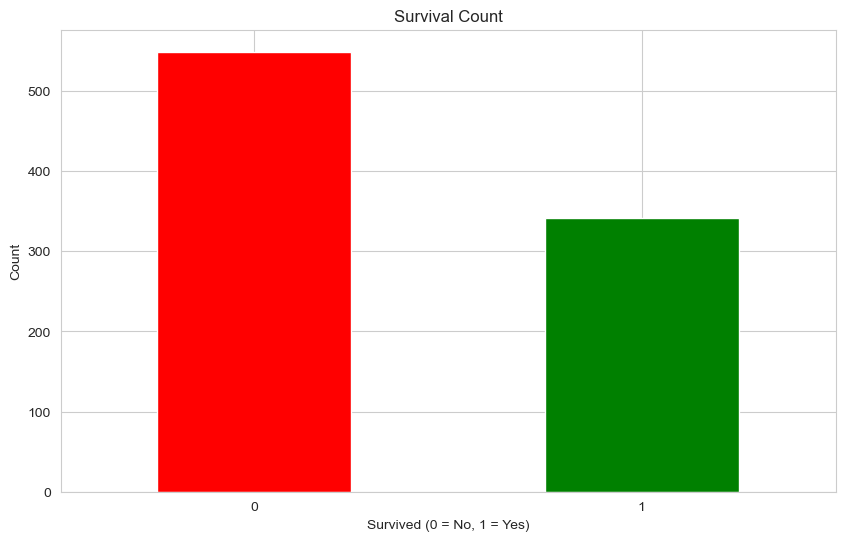

In [39]:
# Contar cuántos sobrevivieron vs murieron
print(df['Survived'].value_counts())

# Visualizar con gráfico de barras
# kind='bar' crea un gráfico de barras vertical
# color=['red', 'green'] asigna rojo a "No sobrevivió" y verde a "Sobrevivió"
df['Survived'].value_counts().plot(kind='bar', color=['red', 'green'])
plt.title('Survival Count')  # Título del gráfico
plt.xlabel('Survived (0 = No, 1 = Yes)')  # Etiqueta del eje X
plt.ylabel('Count')  # Etiqueta del eje Y (cantidad de personas)
plt.xticks(rotation=0)  # Mantener las etiquetas del eje X horizontales
plt.show()

### 6.2 Variable categórica: Sex

Crear un gráfico de barras mostrando la distribución de género.

**Tareas:**

1. Contar los valores: df['Sex'].value_counts()
2. Crear gráfico con colores azul y rosa
3. Título: 'Gender Distribution'

Sex
male      577
female    314
Name: count, dtype: int64


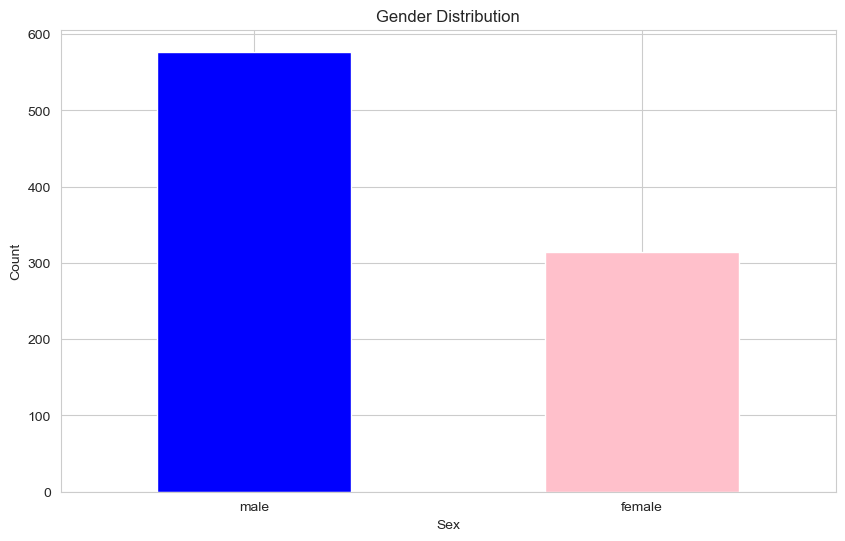

In [40]:
# Contar cuántos hombres y mujeres hay en el dataset
print(df['Sex'].value_counts())

# Visualizar con gráfico de barras
# Mostramos la distribución de género en el Titanic
df['Sex'].value_counts().plot(kind='bar', color=['blue', 'pink'])
plt.title('Gender Distribution')  # Distribución por género
plt.xlabel('Sex')  # Género (male/female)
plt.ylabel('Count')  # Cantidad de personas
plt.xticks(rotation=0)  # Etiquetas horizontales
plt.show()

### 6.3 Variable numérica: Age

Crear un **histograma** para ver la distribución de edades.

**Configuración:**

* kind='hist'
* bins=30 (divide en 30 rangos)
* edgecolor='black'
* alpha=0.7
* color='skyblue'
* Título: 'Age Distribution'
* xlabel: 'Age'
* ylabel: 'Frequency'

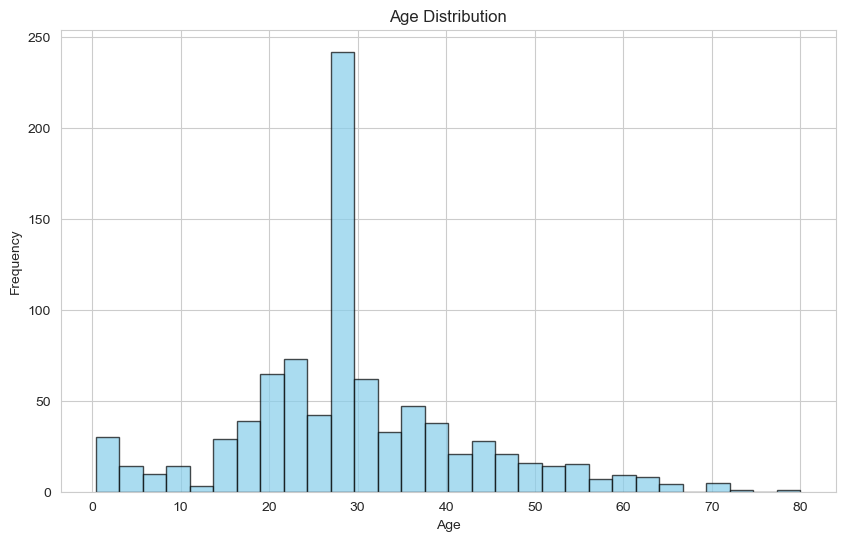

In [41]:
# Histograma para ver la distribución de edades
# bins=30 divide las edades en 30 rangos (ej: 0-3 años, 3-6 años, etc.)
# edgecolor='black' añade un borde negro a cada barra para distinguirlas mejor
# alpha=0.7 hace las barras ligeramente transparentes
df['Age'].plot(kind='hist', bins=30, edgecolor='black', alpha=0.7, color='skyblue')
plt.title('Age Distribution')  # Distribución de edades
plt.xlabel('Age')  # Edad en años
plt.ylabel('Frequency')  # Frecuencia (cuántas personas)
plt.show()

### 6.4 Variable numérica: Fare

Crear un **boxplot** para detectar valores extremos en los precios.

**Configuración:**

* Usar df.boxplot(column='Fare', patch_artist=True)
* Título: 'Fare Distribution'
* ylabel: 'Fare'

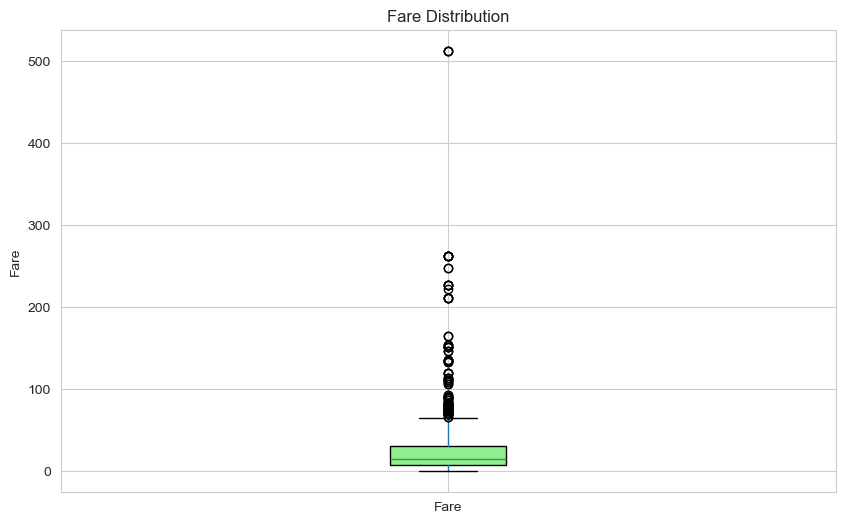

In [42]:
# Boxplot para detectar valores extremos (outliers)
# Un boxplot muestra la distribución de los datos y resalta valores anómalos
df.boxplot(column='Fare', patch_artist=True, 
           boxprops=dict(facecolor='lightgreen'))
plt.title('Fare Distribution')  # Distribución del precio de los tickets
plt.ylabel('Fare')  # Precio del ticket en unidades monetarias
plt.show()

## 🔗 Paso 7: Análisis Bivariado

Analizar la relación entre pares de variables.

### 7.1 Survived vs Sex

**Tareas:**

1. Crear una tabla cruzada con porcentajes por sexo:
    * pd.crosstab(df['Sex'], df['Survived'], normalize='index') * 100
2. Crear un gráfico de barras agrupadas:
    * pd.crosstab(df['Sex'], df['Survived']).plot(kind='bar', color=['red', 'green'])
    * Añadir título, labels y leyenda

**Pregunta a responder:** ¿Quién tuvo más probabilidad de sobrevivir: hombres o mujeres?

In [43]:
# Tabla cruzada para ver la relación entre sexo y supervivencia
# normalize='index' calcula porcentajes por fila (por cada sexo)
survival_by_sex = pd.crosstab(df['Sex'], df['Survived'], normalize='index') * 100
print("Porcentaje de supervivencia por sexo:")
print(survival_by_sex)

Porcentaje de supervivencia por sexo:
Survived          0          1
Sex                           
female    25.796178  74.203822
male      81.109185  18.890815


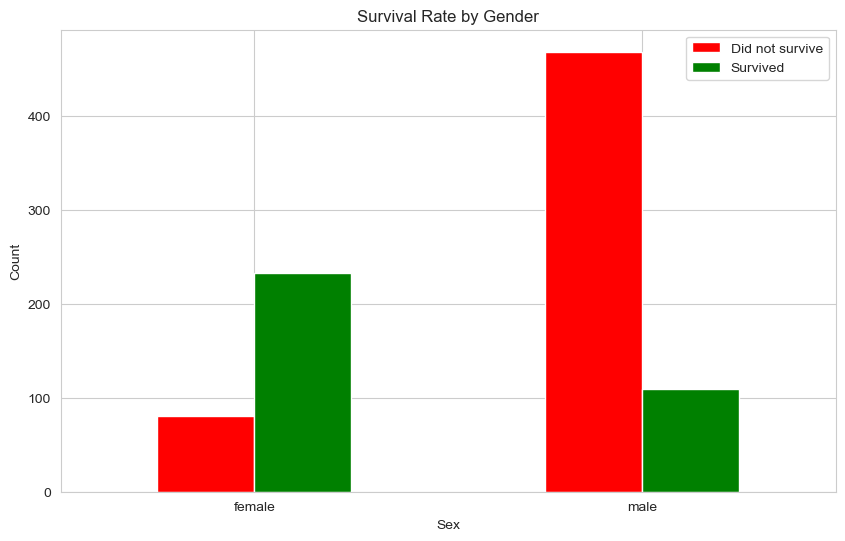

In [44]:
# Gráfico de barras agrupadas para comparar supervivencia por sexo
# Esto nos permite ver visualmente la diferencia entre hombres y mujeres
pd.crosstab(df['Sex'], df['Survived']).plot(kind='bar', color=['red', 'green'])
plt.title('Survival Rate by Gender')  # Tasa de supervivencia por género
plt.xlabel('Sex')  # Género (male/female)
plt.ylabel('Count')  # Cantidad de personas
plt.legend(['Did not survive', 'Survived'])  # Leyenda: rojo=murió, verde=sobrevivió
plt.xticks(rotation=0)  # Mantener etiquetas horizontales
plt.show()

*Las mujeres tuvieron mayor tasa de supervivencia (política de "mujeres y niños primero").*

### 7.2 Survived vs Passenger_Class

Analizar cómo la clase del pasajero afectó la supervivencia.

**Tarea:**

* Crear un gráfico de barras apiladas (stacked=True)
* Usar colores rojo y verde
* Título: 'Survival Rate by Passenger Class'

**Pregunta a responder:** ¿La primera clase tuvo ventaja?

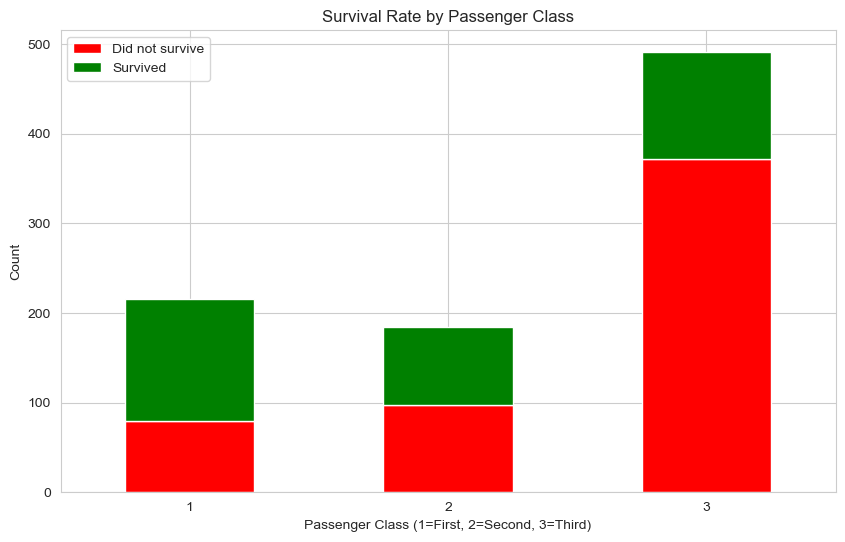

In [45]:
# Análisis de supervivencia por clase de pasajero
# stacked=True apila las barras (muertos + sobrevivientes en la misma columna)
pd.crosstab(df['Passenger_Class'], df['Survived']).plot(kind='bar', stacked=True, 
                                                          color=['red', 'green'])
plt.title('Survival Rate by Passenger Class')  # Supervivencia por clase
plt.xlabel('Passenger Class (1=First, 2=Second, 3=Third)')  # Clase del ticket
plt.ylabel('Count')  # Cantidad de personas
plt.legend(['Did not survive', 'Survived'])  # Leyenda
plt.xticks(rotation=0)
plt.show()

*La primera clase tuvo cierta ventaja quizás por un mejor acceso a los botes salvavidas.*

### 7.3 Age vs Survived

Comparar las distribuciones de edad entre sobrevivientes y no sobrevivientes.

**Tareas:**

1. Crear dos histogramas superpuestos:
    * Sobrevivientes (verde, alpha=0.5)
    * No sobrevivientes (rojo, alpha=0.5)
2. bins=30, edgecolor='black'
3. Añadir leyenda

***Pregunta a responder:*** ¿Los niños tuvieron más probabilidad de sobrevivir?

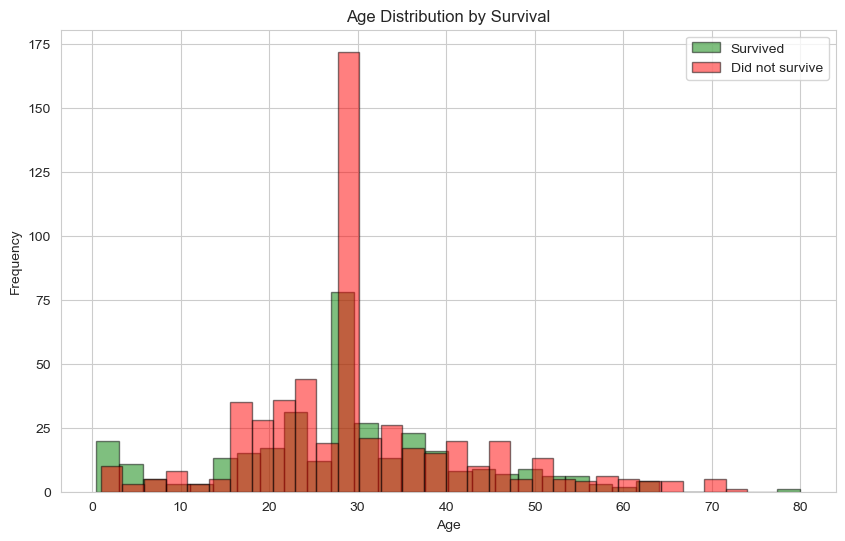

In [46]:
# Distribución de edades por supervivencia
# Comparamos las edades de quienes sobrevivieron vs quienes no
# alpha=0.5 hace los histogramas semi-transparentes para que podamos ver ambos
df[df['Survived']==1]['Age'].plot(kind='hist', bins=30, alpha=0.5, 
                                   label='Survived', color='green', edgecolor='black')
df[df['Survived']==0]['Age'].plot(kind='hist', bins=30, alpha=0.5, 
                                   label='Did not survive', color='red', edgecolor='black')
plt.title('Age Distribution by Survival')  # Distribución de edad según supervivencia
plt.xlabel('Age')  # Edad en años
plt.ylabel('Frequency')  # Frecuencia (cuántas personas)
plt.legend()  # Mostrar leyenda
plt.show()

*Claramente los niños tuvieron prioridad por lo que su probabilidad de sobrevivir fue mayor que la del resto de grupos*

### 7.4 Fare vs Survived

Comparar los precios de tickets entre sobrevivientes y no sobrevivientes.

**Tarea:**

* Crear un boxplot comparativo: df.boxplot(column='Fare', by='Survived')
* Usar plt.suptitle('') para quitar el título automático
* Añadir título y labels

**Pregunta a responder:** ¿Pagar más dinero aumentó las chances de sobrevivir?

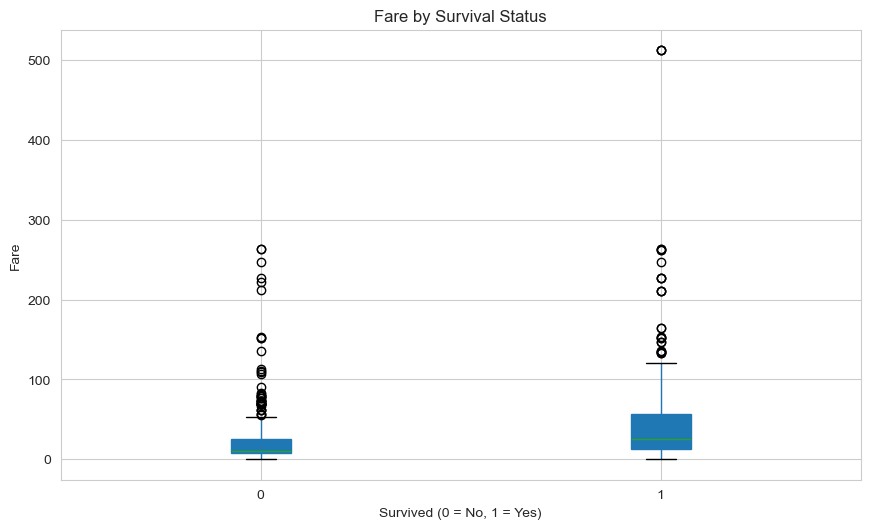

In [47]:
# Boxplot comparativo de precios de tickets por supervivencia
# Comparamos cuánto pagaron los que sobrevivieron vs los que no
df.boxplot(column='Fare', by='Survived', patch_artist=True)
plt.title('Fare by Survival Status')  # Precio del ticket según supervivencia
plt.suptitle('')  # Quitar título automático que genera pandas
plt.xlabel('Survived (0 = No, 1 = Yes)')  # Supervivencia
plt.ylabel('Fare')  # Precio del ticket
plt.show()

*Sí, debido a que normalmente los tickets de primera clase (de mayor precio) no solo están en mejores ubicaciones del barco sino que además cuentán con mejores accesos a los botes salvavidas.*

## 🎨 Paso 8: Análisis Multivariado

Analizar múltiples variables simultáneamente.

### 8.1 Matriz de correlación

**Tareas:**

1. Seleccionar solo las columnas numéricas:
    * numeric_df = df.select_dtypes(include=[np.number])
2. Calcular la correlación:
    * correlation = numeric_df.corr()
3. Imprimir la matriz

**¿Qué buscar?**

* Valores cercanos a 1: correlación positiva fuerte
* Valores cercanos a -1: correlación negativa fuerte
* Valores cercanos a 0: sin correlación

In [48]:
# Calcular correlaciones SOLO entre variables numéricas
# select_dtypes(include=[np.number]) selecciona solo columnas con números
# Esto evita errores con columnas de texto como 'Sex' o 'Embarked'
numeric_df = df.select_dtypes(include=[np.number])
correlation = numeric_df.corr()
print("Matriz de correlación entre variables numéricas:")
print(correlation)

Matriz de correlación entre variables numéricas:
                  Survived  Passenger_Class       Age  Siblings_Spouses  \
Survived          1.000000        -0.338481 -0.064910         -0.035322   
Passenger_Class  -0.338481         1.000000 -0.339898          0.083081   
Age              -0.064910        -0.339898  1.000000         -0.233296   
Siblings_Spouses -0.035322         0.083081 -0.233296          1.000000   
Parents_Children  0.081629         0.018443 -0.172482          0.414838   
Fare              0.257307        -0.549500  0.096688          0.159651   

                  Parents_Children      Fare  
Survived                  0.081629  0.257307  
Passenger_Class           0.018443 -0.549500  
Age                      -0.172482  0.096688  
Siblings_Spouses          0.414838  0.159651  
Parents_Children          1.000000  0.216225  
Fare                      0.216225  1.000000  


### 8.2 Heatmap de correlación

Visualizar la matriz de correlación con un mapa de calor.

**Configuración:**

* plt.figure(figsize=(10, 8))
* sns.heatmap(correlation, annot=True, cmap='coolwarm', center=0, linewidths=1, fmt='.2f', square=True)
* Título: 'Correlation Matrix - Titanic Dataset'
* Usa plt.tight_layout()

Interpretación:

* Rojo/naranja = correlación positiva
* Azul = correlación negativa
* Blanco = sin correlación

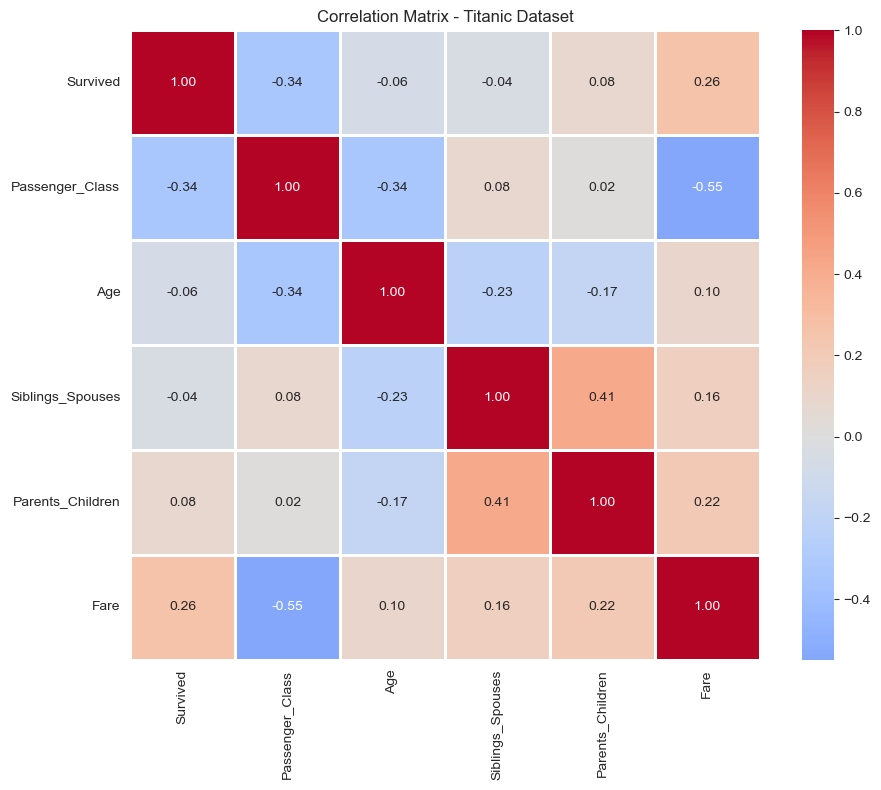

In [49]:
# Crear un heatmap (mapa de calor) para visualizar las correlaciones
plt.figure(figsize=(10, 8))  # Tamaño del gráfico
# annot=True muestra los números dentro de cada celda
# cmap='coolwarm' usa colores: rojo=positivo, azul=negativo
# center=0 centra la escala de colores en cero
# linewidths=1 añade líneas entre celdas para mejor legibilidad
sns.heatmap(correlation, annot=True, cmap='coolwarm', center=0, 
            linewidths=1, fmt='.2f', square=True)
plt.title('Correlation Matrix - Titanic Dataset')  # Título
plt.tight_layout()  # Ajusta el gráfico para que no se corten las etiquetas
plt.show()

### 8.3 Pairplot

Crear una matriz de gráficos mostrando relaciones entre todas las variables numéricas.

**Configuración:**

* sns.pairplot(numeric_df, hue='Survived', palette={0: 'red', 1: 'green'}, diag_kind='hist', plot_kws={'alpha': 0.6})
* Añadir título con plt.suptitle('Pairplot of Numeric Variables by Survival', y=1.02)

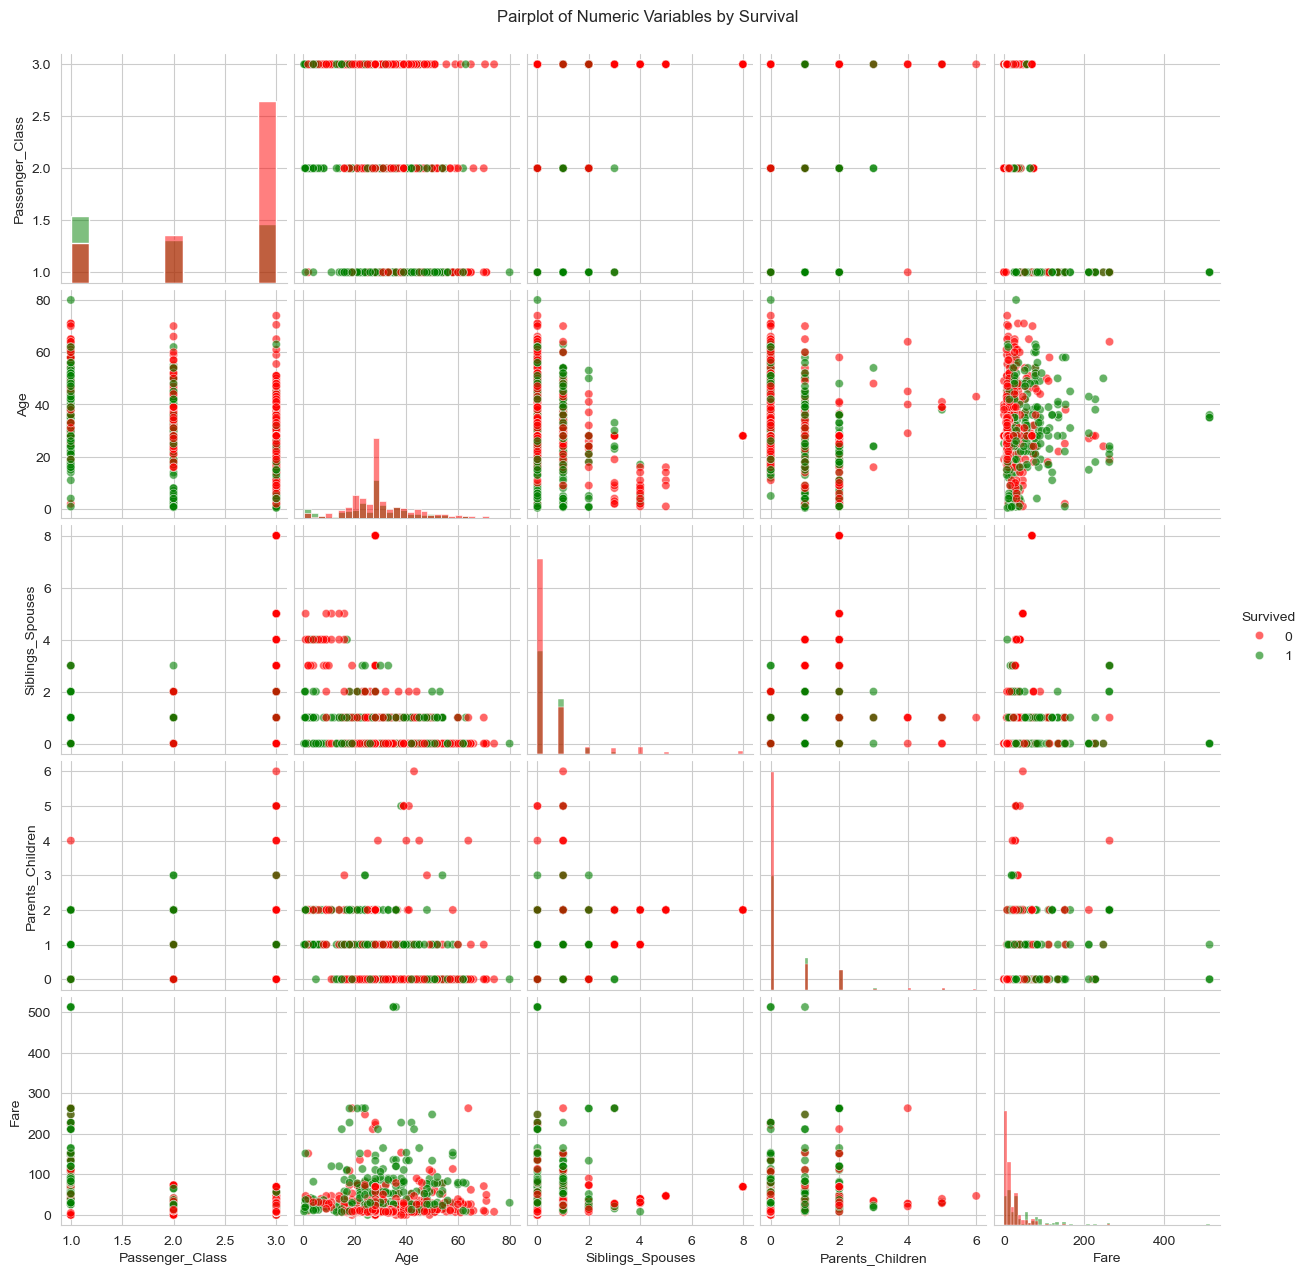

In [50]:
# Visualizar relaciones entre todas las variables numéricas
# hue='Survived' colorea los puntos según si sobrevivieron (verde) o no (rojo)
# palette={0: 'red', 1: 'green'} define los colores específicos
# Este gráfico puede tardar un poco porque crea muchas visualizaciones
sns.pairplot(numeric_df, hue='Survived', palette={0: 'red', 1: 'green'}, 
             diag_kind='hist', plot_kws={'alpha': 0.6})
plt.suptitle('Pairplot of Numeric Variables by Survival', y=1.02)  # Título general
plt.show()

## 📊 Paso 9: Feature Engineering Básico

Crear nuevas variables a partir de las existentes.

### 9.1 Crear variable Family_Size

**Tareas:**

1. Crear la columna: df['Family_Size'] = df['Siblings_Spouses'] + df['Parents_Children'] + 1
2. Mostrar las columnas relacionadas: df[['Siblings_Spouses', 'Parents_Children', 'Family_Size']].head(10)
3. Crear un histograma de Family_Size con:
    * bins=10
    * color='orange'
    * edgecolor='black'

In [51]:
# Sumar hermanos/cónyuges + padres/hijos + 1 (el pasajero mismo)
df['Family_Size'] = df['Siblings_Spouses'] + df['Parents_Children'] + 1

# Ver las nuevas columnas creadas
print("Nueva columna Family_Size creada:")
df[['Siblings_Spouses', 'Parents_Children', 'Family_Size']].head(10)

Nueva columna Family_Size creada:


,Siblings_Spouses,Parents_Children,Family_Size
0,1,0,2
1,1,0,2
2,0,0,1
3,1,0,2
4,0,0,1
5,0,0,1
6,0,0,1
7,3,1,5
8,0,2,3
9,1,0,2


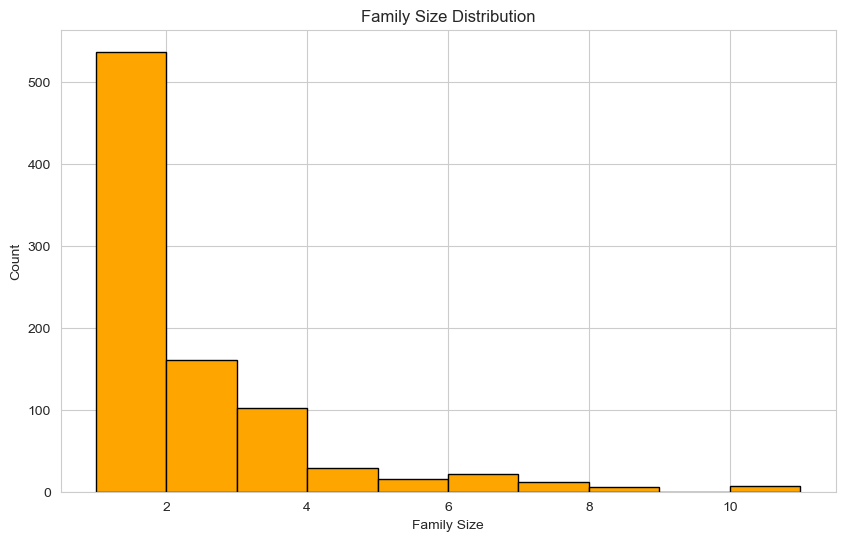

In [52]:
# Visualizar la distribución del tamaño de familia
df['Family_Size'].plot(kind='hist', bins=10, edgecolor='black', color='orange')
plt.title('Family Size Distribution')  # Distribución del tamaño de familia
plt.xlabel('Family Size')  # Tamaño de familia (1=solo, 2+=con familia)
plt.ylabel('Count')  # Cantidad de personas
plt.show()

### 9.2 Crear variable Is_Alone

**Tareas:**

1. Crear variable binaria: df['Is_Alone'] = (df['Family_Size'] == 1).astype(int)
2. Mostrar las columnas: df[['Family_Size', 'Is_Alone']].head(10)
3. Analizar supervivencia con crosstab y gráfico de barras

**Pregunta a responder:** ¿Viajar solo fue ventaja o desventaja?

In [53]:
# Crear variable binaria: 1 si viaja solo, 0 si viaja con familia
df['Is_Alone'] = (df['Family_Size'] == 1).astype(int)

# Ver la nueva columna
print("Nueva columna Is_Alone creada:")
df[['Family_Size', 'Is_Alone']].head(10)

Nueva columna Is_Alone creada:


,Family_Size,Is_Alone
0,2,0
1,2,0
2,1,1
3,2,0
4,1,1
5,1,1
6,1,1
7,5,0
8,3,0
9,2,0


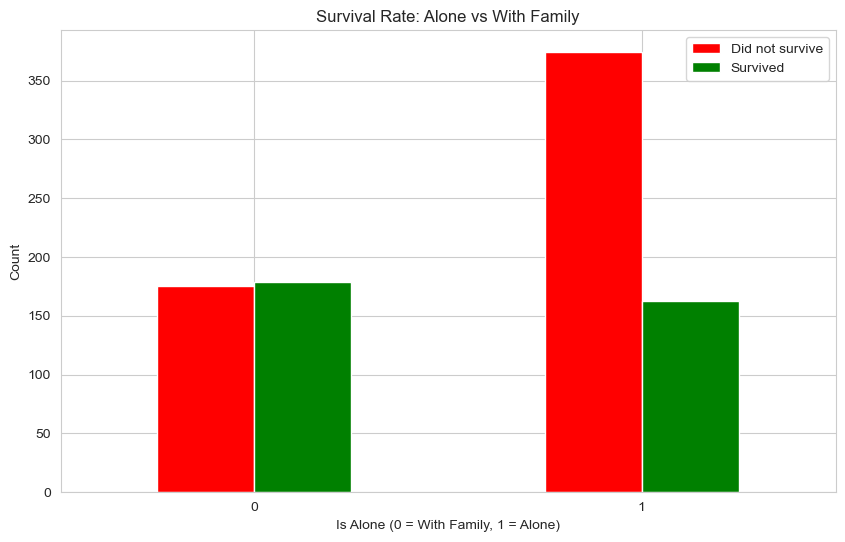

In [54]:
# Analizar supervivencia según si viajaban solos o acompañados
# Esto nos ayuda a responder: ¿viajar solo aumentó o disminuyó las chances de sobrevivir?
pd.crosstab(df['Is_Alone'], df['Survived']).plot(kind='bar', color=['red', 'green'])
plt.title('Survival Rate: Alone vs With Family')  # Supervivencia: solo vs acompañado
plt.xlabel('Is Alone (0 = With Family, 1 = Alone)')  # 0=con familia, 1=solo
plt.ylabel('Count')  # Cantidad de personas
plt.xticks(rotation=0)
plt.legend(['Did not survive', 'Survived'])
plt.show()

*Viajar solo fue una desventaja en términos de supervivencia, ya que, al viajar con familia la probabilidad de sobrevivir claramente fue más equilibrada, lo que sugiere que el viajar con familia tal vez pudiese haber ayudado a sobrevivir.*

### 9.3 Crear variable Age_Group

**Tareas:**

1. Categorizar las edades:
df['Age_Group'] = pd.cut(df['Age'],
                         bins=[0, 12, 18, 35, 60, 100],
                         labels=['Child', 'Teenager', 'Young Adult', 'Adult', 'Senior'])
2. Mostrar: df[['Age', 'Age_Group']].head(15)
3. Crear gráfico de barras de supervivencia por grupo de edad

**Pregunta a responder:** ¿Los niños tuvieron prioridad ("mujeres y niños primero")?

In [55]:
# Categorizar edades en grupos significativos
# bins define los límites de cada grupo
# labels define los nombres de cada categoría
df['Age_Group'] = pd.cut(df['Age'], 
                         bins=[0, 12, 18, 35, 60, 100], 
                         labels=['Child', 'Teenager', 'Young Adult', 'Adult', 'Senior'])

# Ver la nueva columna de grupos de edad
print("Nueva columna Age_Group creada:")
df[['Age', 'Age_Group']].head(15)

Nueva columna Age_Group creada:


,Age,Age_Group
0,22.0,Young Adult
1,38.0,Adult
2,26.0,Young Adult
3,35.0,Young Adult
4,35.0,Young Adult
5,28.0,Young Adult
6,54.0,Adult
7,2.0,Child
8,27.0,Young Adult
9,14.0,Teenager


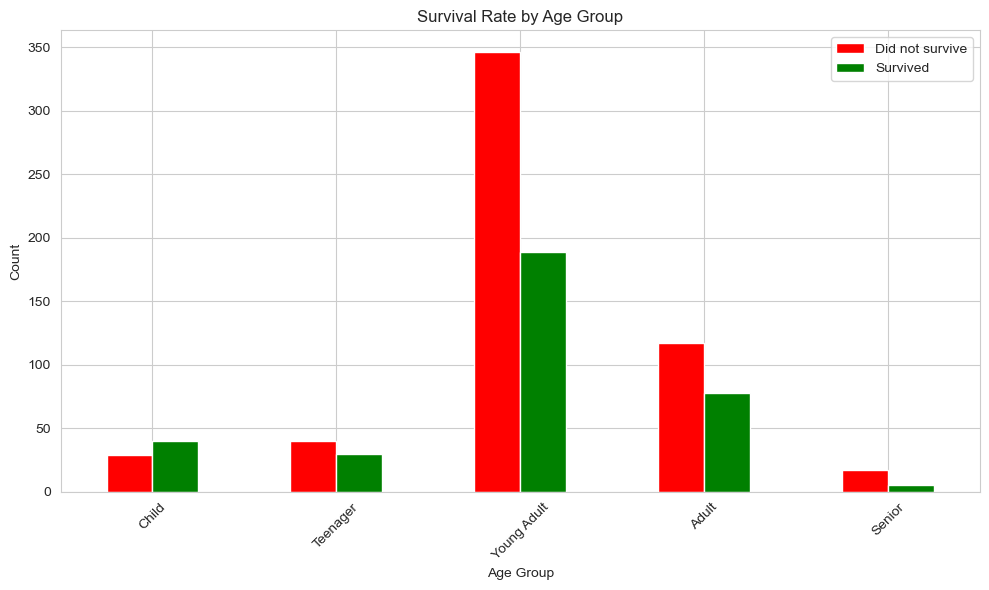

In [56]:
# Analizar supervivencia por grupo de edad
# Esto nos ayuda a ver si "mujeres y niños primero" fue real
pd.crosstab(df['Age_Group'], df['Survived']).plot(kind='bar', color=['red', 'green'])
plt.title('Survival Rate by Age Group')  # Supervivencia por grupo de edad
plt.xlabel('Age Group')  # Grupo de edad
plt.ylabel('Count')  # Cantidad de personas
plt.xticks(rotation=45)  # Rotar etiquetas 45 grados para que no se superpongan
plt.legend(['Did not survive', 'Survived'])
plt.tight_layout()  # Ajustar para que no se corten las etiquetas
plt.show()

*Efectivamente, los niños tuvieron prioridad y por tanto mayor posibilidad de sobrevivir.*

## 📝 Paso 10: Conclusiones

Después de todo el análisis, se escriben los hallazgos:

### 10.1 Tasa de supervivencia general

Calcular qué porcentaje del total de pasajeros sobrevivió.

**Formula:**(df['Survived'].sum() / len(df)) * 100

In [68]:
#Tasa de supervivencia general
survival_rate = (df['Survived'].sum() / len(df)) * 100
print(f"Tasa de supervivencia general: {survival_rate:.2f}%\n")

Tasa de supervivencia general: 38.38%



### 10.2 Supervivencia por sexo

Calcular el porcentaje de supervivencia para hombres y mujeres por separado.

**Pista:** df.groupby('Sex')['Survived'].mean() * 100

In [67]:
#Supervivencia por sexo
survival_by_sex = df.groupby('Sex')['Survived'].mean() * 100
print("Tasa de supervivencia por sexo:")
print(survival_by_sex)
print()

Tasa de supervivencia por sexo:
Sex
female    74.203822
male      18.890815
Name: Survived, dtype: float64



### 10.3 Supervivencia por clase

Calcular el porcentaje de supervivencia para cada clase (1, 2, 3).

**Pista:** df.groupby('Passenger_Class')['Survived'].mean() * 100

In [65]:
#Supervivencia por clase
survival_by_class = df.groupby('Passenger_Class')['Survived'].mean() * 100
print("Tasa de supervivencia por clase:")
print(survival_by_class)
print()

Tasa de supervivencia por clase:
Passenger_Class
1    62.962963
2    47.282609
3    24.236253
Name: Survived, dtype: float64



### 10.4 Edad promedio por supervivencia

Comparar la edad promedio de:

* Los que sobrevivieron
* Los que no sobrevivieron

**Pista:** df.groupby('Survived')['Age'].mean()

In [66]:
#Edad promedio de sobrevivientes vs no sobrevivientes
avg_age = df.groupby('Survived')['Age'].mean()
print("Edad promedio:")
print(f"   No sobrevivientes: {avg_age[0]:.2f} años")
print(f"   Sobrevivientes: {avg_age[1]:.2f} años")

Edad promedio:
   No sobrevivientes: 30.03 años
   Sobrevivientes: 28.29 años
